In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
with open('training_vae_mse_losses_05_05.txt', 'r') as f:
     mse_losses = json.loads(f.read())

with open('training_vae_nmse_losses_05_05.txt', 'r') as f:
     nmse_losses = json.loads(f.read())


configs = np.array(list(mse_losses.keys()))
mse_losses_array = np.array([list(losses.values()) for losses in mse_losses.values()])
nmse_losses_array = np.array([list(losses.values()) for losses in nmse_losses.values()])

mean_mse_loss = np.mean(mse_losses_array, axis=1)
mean_nmse_loss = np.mean(nmse_losses_array, axis=1)

best_mean_mse_indices = np.argsort(mean_mse_loss)[:5]
best_mean_mse_models = configs[best_mean_mse_indices]
best_mean_mse_losses = mean_mse_loss[best_mean_mse_indices]

best_mean_nmse_indices = np.argsort(mean_nmse_loss)[:5]
best_mean_nmse_models = configs[best_mean_nmse_indices]
best_mean_nmse_losses = mean_nmse_loss[best_mean_nmse_indices]

In [33]:
configs

array(['vae_0.0015_1000_100', 'vae_0.0015_1000_200',
       'vae_0.0015_1000_300', 'vae_0.0015_1500_100',
       'vae_0.0015_1500_200', 'vae_0.0015_1500_300', 'vae_0.0015_500_100',
       'vae_0.0015_500_200', 'vae_0.0015_500_300', 'vae_0.001_1000_100',
       'vae_0.001_1000_200', 'vae_0.001_1000_300', 'vae_0.001_1500_100',
       'vae_0.001_1500_200', 'vae_0.001_1500_300', 'vae_0.001_500_100',
       'vae_0.001_500_200', 'vae_0.001_500_300', 'vae_0.002_1000_100',
       'vae_0.002_1000_200', 'vae_0.002_1000_300', 'vae_0.002_1500_100',
       'vae_0.002_1500_200', 'vae_0.002_1500_300', 'vae_0.002_500_100',
       'vae_0.002_500_200', 'vae_0.002_500_300'], dtype='<U19')

Text(0.5, 1.0, 'Best five mean MSE losses')

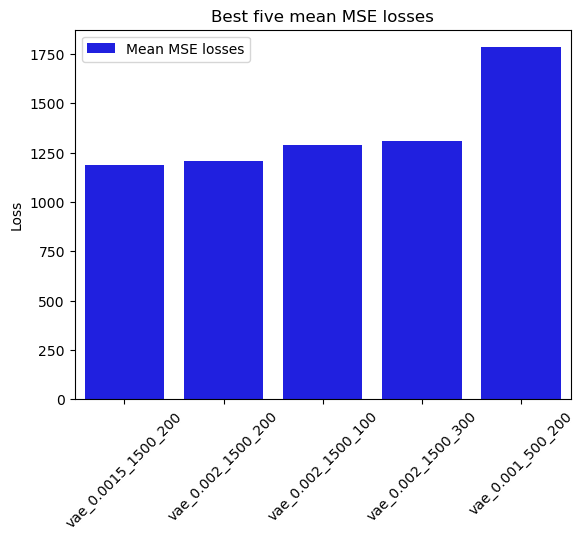

In [7]:
sns.barplot(x=best_mean_mse_models, y=best_mean_mse_losses, color='blue', label='Mean MSE losses')
plt.xticks(rotation=45)
plt.ylabel('Loss')
plt.title('Best five mean MSE losses')

Text(0.5, 1.0, 'Best five mean NMSE losses')

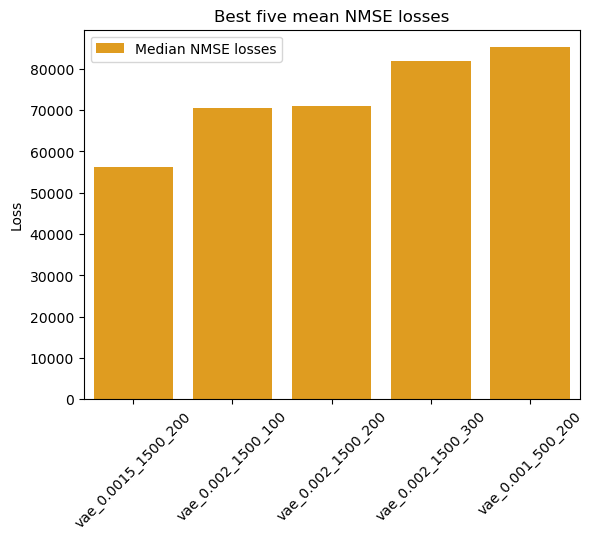

In [8]:
sns.barplot(x=best_mean_nmse_models, y=best_mean_nmse_losses, color='orange', label='Median NMSE losses')
plt.xticks(rotation=45)
plt.ylabel('Loss')
plt.title('Best five mean NMSE losses')

In [28]:
P5, Q1, median_loss, Q3, P95, worst = np.quantile(mse_losses_array, [0.05, 0.25, 0.5, 0.75, 0.95, 1], axis=1)
n_P5, n_Q1, n_median_loss, n_Q3, n_P95, n_worst = np.quantile(nmse_losses_array, [0.05, 0.25, 0.5, 0.75, 0.95, 1], axis=1)

best_P95_mse_indices = np.argsort(P95)[:5]
best_P95_mse_models = configs[best_P95_mse_indices]
best_P95_mse_losses = P95[best_P95_mse_indices]

best_median_mse_indices = np.argsort(median_loss)[:5]
best_median_mse_models = configs[best_median_mse_indices]
best_median_mse_losses = median_loss[best_median_mse_indices]

best_P95_nmse_indices = np.argsort(n_P95)[:5]
best_P95_nmse_models = configs[best_P95_nmse_indices]
best_P95_nmse_losses = n_P95[best_P95_nmse_indices]

best_median_nmse_indices = np.argsort(n_median_loss)[:5]
best_median_nmse_models = configs[best_median_nmse_indices]
best_median_nmse_losses = n_median_loss[best_median_nmse_indices]

mse_stats = {
            #'mean': mean_mse_loss[best_P95_mse_indices],
            'P5': P5[best_P95_mse_indices],
            'Q1': Q1[best_P95_mse_indices],
            'median': median_loss[best_P95_mse_indices],
            'Q3': Q3[best_P95_mse_indices],
            'P95': P95[best_P95_mse_indices],
            #'worst': worst[best_P95_mse_indices]
            }

mse_stats_df = pd.DataFrame(mse_stats, index=best_P95_mse_models)
mse_stats_df = mse_stats_df.reset_index().rename(columns={"index": "Model"})

nmse_stats = {
            #'mean': mean_nmse_loss[best_P95_nmse_indices],
            'P5': n_P5[best_P95_nmse_indices],
            'Q1': n_Q1[best_P95_nmse_indices],
            'median': n_median_loss[best_P95_nmse_indices],
            'Q3': n_Q3[best_P95_nmse_indices],
            'P95': n_P95[best_P95_nmse_indices],
            #'worst': n_worst[best_P95_nmse_indices]
            }

nmse_stats_df = pd.DataFrame(nmse_stats, index=best_P95_nmse_models)
nmse_stats_df = nmse_stats_df.reset_index().rename(columns={"index": "Model"})

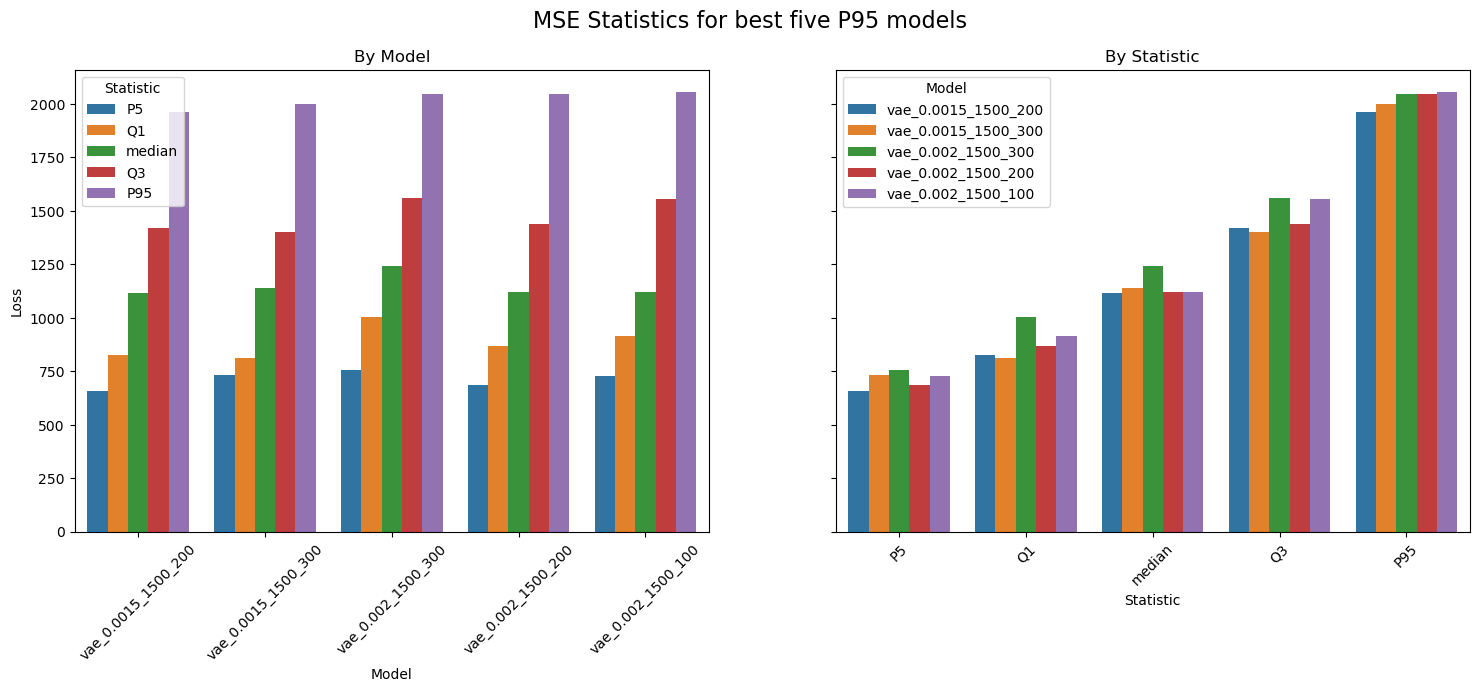

In [29]:
mse_stats_long = mse_stats_df.melt(id_vars="Model", var_name="Statistic", value_name="Value")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle("MSE Statistics for best five P95 models", fontsize=16)

sns.barplot(data=mse_stats_long, x="Model", y="Value", hue="Statistic", ax=axes[0])
axes[0].set_title("By Model")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("Model")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Statistic")
#axes[0].set_yscale('log')

sns.barplot(data=mse_stats_long, x="Statistic", y="Value", hue="Model", ax=axes[1])
axes[1].set_title("By Statistic")
axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Statistic")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Model")
#axes[1].set_yscale('log')

# Adjust layout
plt.show()

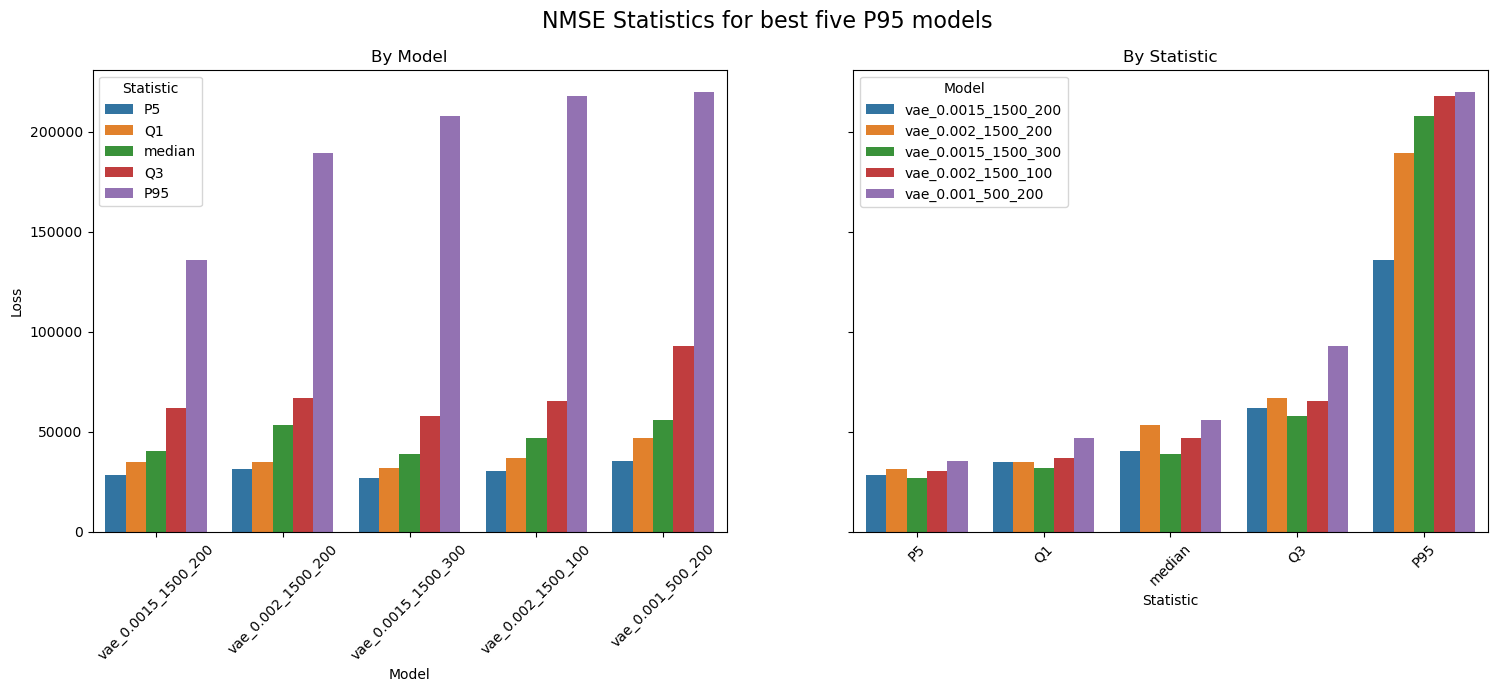

In [30]:
nmse_stats_long = nmse_stats_df.melt(id_vars="Model", var_name="Statistic", value_name="Value")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle("NMSE Statistics for best five P95 models", fontsize=16)

sns.barplot(data=nmse_stats_long, x="Model", y="Value", hue="Statistic", ax=axes[0])
axes[0].set_title("By Model")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("Model")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Statistic")

sns.barplot(data=nmse_stats_long, x="Statistic", y="Value", hue="Model", ax=axes[1])
axes[1].set_title("By Statistic")
axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Statistic")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Model")

# Adjust layout
plt.show()

In [34]:
best_P95_mse_models[0]

np.str_('vae_0.0015_1500_200')

In [ ]:
best_hidden_mse_models = [model for model in mse_losses.keys() if "_".join(model.split("_")[2]) == "_".join(best_P95_mse_models[0].split("_")[2])]
best_hidden_nmse_models = [model for model in nmse_losses.keys() if "_".join(model.split("_")[2]) == "_".join(best_P95_nmse_models[0].split("_")[2])]

best_hidden_mse_models.sort(key=lambda x: x.split("_")[2:4], reverse=True)
best_hidden_nmse_models.sort(key=lambda x: x.split("_")[2:4], reverse=True)

best_hidden_mse_losses = np.array([list(mse_losses[model].values()) for model in best_hidden_mse_models])
best_hidden_nmse_losses = np.array([list(nmse_losses[model].values()) for model in best_hidden_nmse_models])

mean = np.mean(best_hidden_mse_losses, axis=1)
n_mean = np.mean(best_hidden_nmse_losses, axis=1)

P5, Q1, median_loss, Q3, P95, worst = np.quantile(best_hidden_mse_losses, [0.05, 0.25, 0.5, 0.75, 0.95, 1], axis=1)
n_P5, n_Q1, n_median_loss, n_Q3, n_P95, n_worst = np.quantile(best_hidden_nmse_losses, [0.05, 0.25, 0.5, 0.75, 0.95, 1], axis=1)

mse_stats = {
            'mean': mean,
            'P5': P5,
            'Q1': Q1,
            'median': median_loss,
            'Q3': Q3,
            'P95': P95,
            'worst': worst
            }

mse_stats_df = pd.DataFrame(mse_stats, index=best_hidden_mse_models)
mse_stats_df = mse_stats_df.reset_index().rename(columns={"index": "Model"})

nmse_stats = {
            'mean': n_mean,
            'P5': n_P5,
            'Q1': n_Q1,
            'median': n_median_loss,
            'Q3': n_Q3,
            'P95': n_P95,
            'worst': n_worst
            }

nmse_stats_df = pd.DataFrame(nmse_stats, index=best_hidden_nmse_models)
nmse_stats_df = nmse_stats_df.reset_index().rename(columns={"index": "Model"})

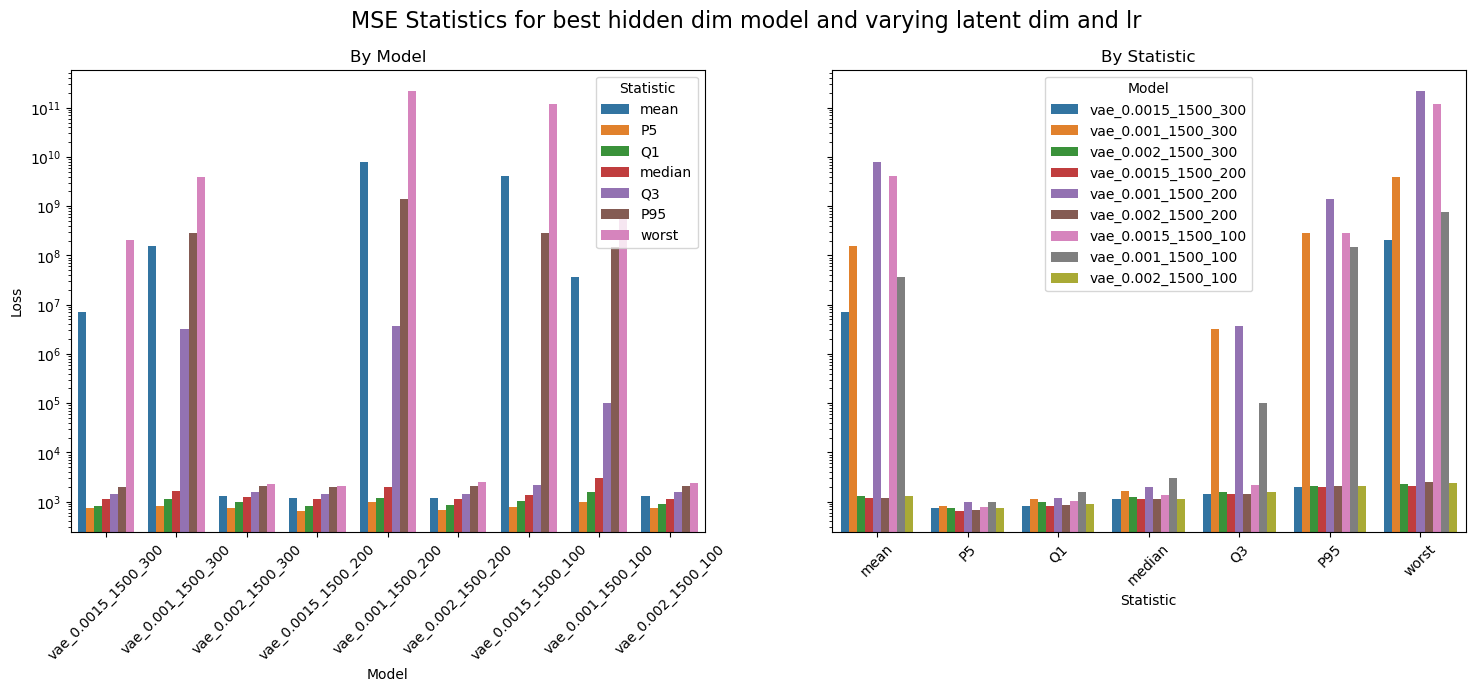

In [52]:
mse_stats_long = mse_stats_df.melt(id_vars="Model", var_name="Statistic", value_name="Value")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle("MSE Statistics for best hidden dim model and varying latent dim and lr", fontsize=16)

sns.barplot(data=mse_stats_long, x="Model", y="Value", hue="Statistic", ax=axes[0])
axes[0].set_title("By Model")
axes[0].set_ylabel("Loss")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Statistic")
axes[0].set_yscale('log')

sns.barplot(data=mse_stats_long, x="Statistic", y="Value", hue="Model", ax=axes[1])
axes[1].set_title("By Statistic")
axes[1].set_ylabel("Loss")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Model")
axes[1].set_yscale('log')

# Adjust layout
plt.show()

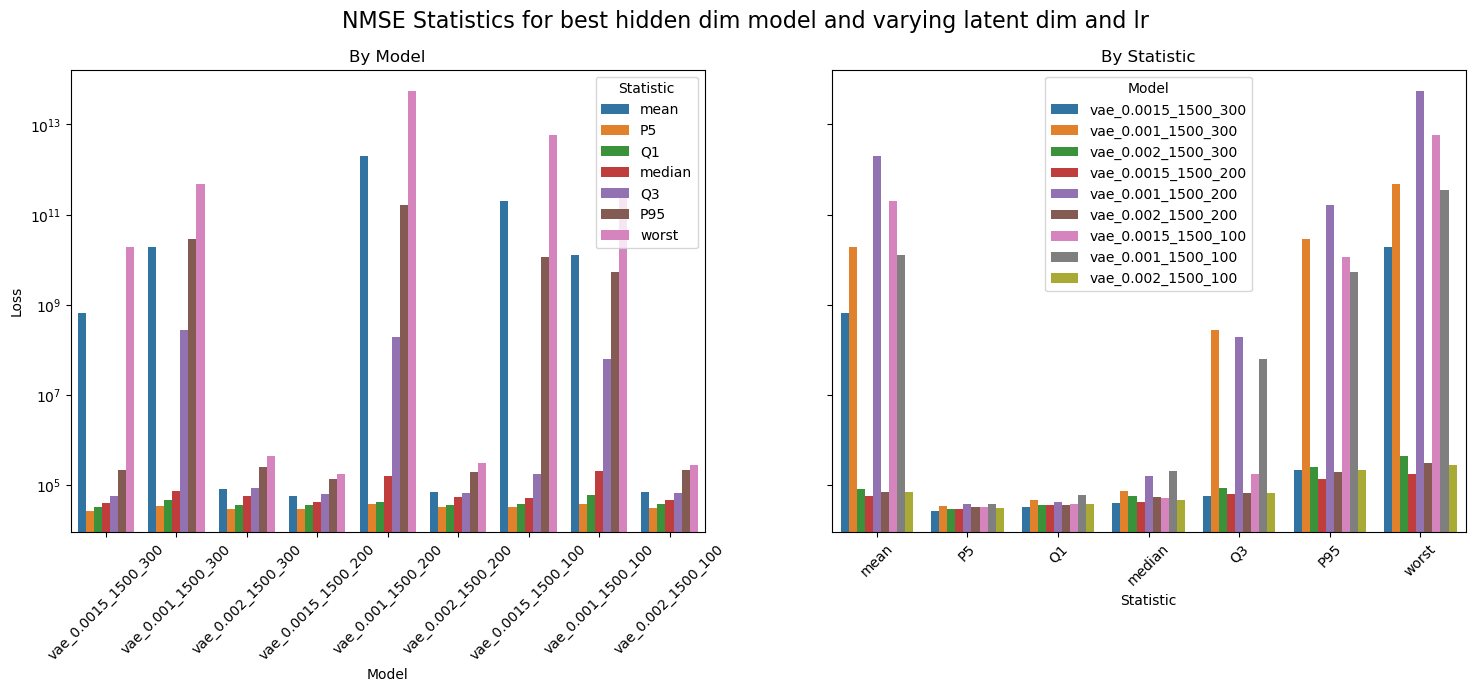

In [54]:
nmse_stats_long = nmse_stats_df.melt(id_vars="Model", var_name="Statistic", value_name="Value")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle("NMSE Statistics for best hidden dim model and varying latent dim and lr", fontsize=16)

sns.barplot(data=nmse_stats_long, x="Model", y="Value", hue="Statistic", ax=axes[0])
axes[0].set_title("By Model")
axes[0].set_ylabel("Loss")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Statistic")
axes[0].set_yscale('log')

sns.barplot(data=nmse_stats_long, x="Statistic", y="Value", hue="Model", ax=axes[1])
axes[1].set_title("By Statistic")
axes[1].set_ylabel("Loss")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Model")
axes[1].set_yscale('log')

# Adjust layout
plt.show()

In [58]:
best_latent_mse_models = [model for model in mse_losses.keys() if "_".join(model.split("_")[3]) == "_".join(best_P95_mse_models[0].split("_")[3])]
best_latent_nmse_models = [model for model in nmse_losses.keys() if "_".join(model.split("_")[3]) == "_".join(best_P95_nmse_models[0].split("_")[3])]

best_latent_mse_models.sort(key=lambda x: int(x.split("_")[2]), reverse=True)
best_latent_nmse_models.sort(key=lambda x: int(x.split("_")[2]), reverse=True)

best_latent_mse_losses = np.array([list(mse_losses[model].values()) for model in best_latent_mse_models])
best_latent_nmse_losses = np.array([list(nmse_losses[model].values()) for model in best_latent_nmse_models])

mean = np.mean(best_latent_mse_losses, axis=1)
n_mean = np.mean(best_latent_nmse_losses, axis=1)

P5, Q1, median_loss, Q3, P95, worst = np.quantile(best_latent_mse_losses, [0.05, 0.25, 0.5, 0.75, 0.95, 1], axis=1)
n_P5, n_Q1, n_median_loss, n_Q3, n_P95, n_worst = np.quantile(best_latent_nmse_losses, [0.05, 0.25, 0.5, 0.75, 0.95, 1], axis=1)

mse_stats = {
            'mean': mean,
            'P5': P5,
            'Q1': Q1,
            'median': median_loss,
            'Q3': Q3,
            'P95': P95,
            'worst': worst
            }

mse_stats_df = pd.DataFrame(mse_stats, index=best_latent_mse_models)
mse_stats_df = mse_stats_df.reset_index().rename(columns={"index": "Model"})

nmse_stats = {
            'mean': n_mean,
            'P5': n_P5,
            'Q1': n_Q1,
            'median': n_median_loss,
            'Q3': n_Q3,
            'P95': n_P95,
            'worst': n_worst
            }

nmse_stats_df = pd.DataFrame(nmse_stats, index=best_latent_nmse_models)
nmse_stats_df = nmse_stats_df.reset_index().rename(columns={"index": "Model"})

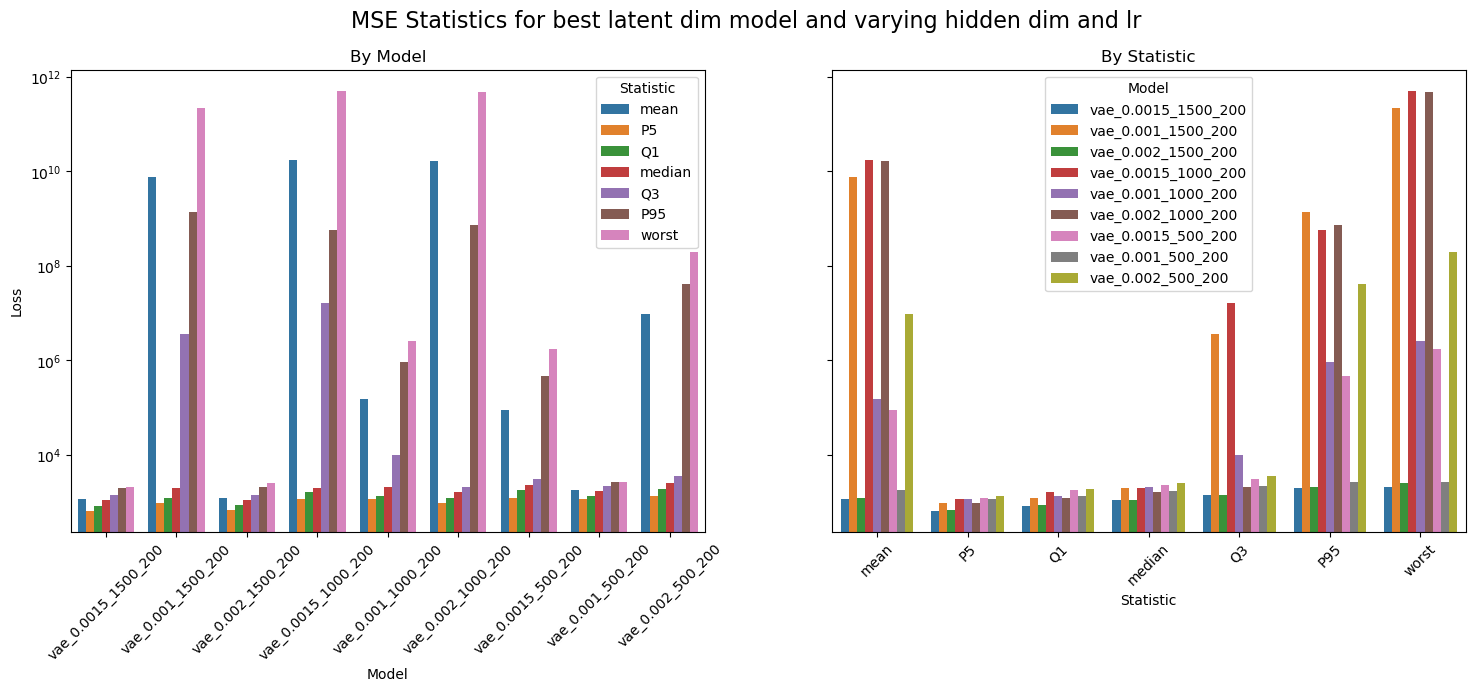

In [59]:
mse_stats_long = mse_stats_df.melt(id_vars="Model", var_name="Statistic", value_name="Value")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle("MSE Statistics for best latent dim model and varying hidden dim and lr", fontsize=16)

sns.barplot(data=mse_stats_long, x="Model", y="Value", hue="Statistic", ax=axes[0])
axes[0].set_title("By Model")
axes[0].set_ylabel("Loss")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Statistic")
axes[0].set_yscale('log')

sns.barplot(data=mse_stats_long, x="Statistic", y="Value", hue="Model", ax=axes[1])
axes[1].set_title("By Statistic")
axes[1].set_ylabel("Loss")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Model")
axes[1].set_yscale('log')

# Adjust layout
plt.show()

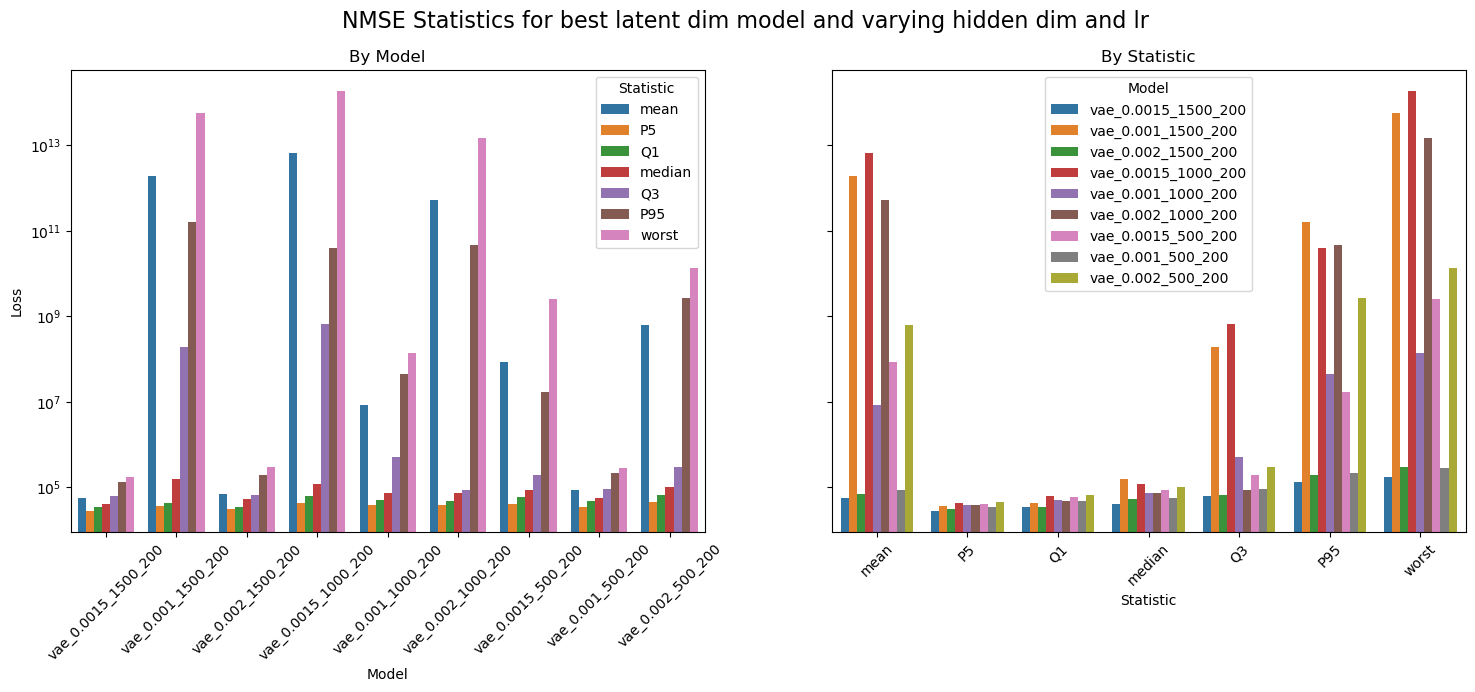

In [61]:
nmse_stats_long = nmse_stats_df.melt(id_vars="Model", var_name="Statistic", value_name="Value")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle("NMSE Statistics for best latent dim model and varying hidden dim and lr", fontsize=16)

sns.barplot(data=nmse_stats_long, x="Model", y="Value", hue="Statistic", ax=axes[0])
axes[0].set_title("By Model")
axes[0].set_ylabel("Loss")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Statistic")
axes[0].set_yscale('log')

sns.barplot(data=nmse_stats_long, x="Statistic", y="Value", hue="Model", ax=axes[1])
axes[1].set_title("By Statistic")
axes[1].set_ylabel("Loss")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Model")
axes[1].set_yscale('log')

# Adjust layout
plt.show()